# Chapter 5 Python Lab  
## Cross Products, Curves, and Motion in Space

This computer lab accompanies **Chapter 5: Cross Products, Curves, and Motion in Space**.

The chapter has two main themes:

1. **Cross products**: orientation, normal vectors, area, and volume in $\mathbb R^3$.
2. **Vector-valued functions**: curves, velocity, speed, acceleration, arc length, unit tangent vectors, and curvature.

This lab is designed as an active computational notebook. It includes guided examples, reusable Python functions, visualizations, reference solutions, and a mini-project on reconstructing motion from sampled data.

The only required packages are `numpy` and `matplotlib`.

## Lab learning goals

By the end of this lab, you should be able to:

1. compute and check cross products numerically;
2. visualize $\mathbf a$, $\mathbf b$, and $\mathbf a\times\mathbf b$;
3. use $|\mathbf a\times\mathbf b|$ for parallelogram and triangle area;
4. use $\mathbf a\cdot(\mathbf b\times\mathbf c)$ for signed volume;
5. compute equations of planes from three points;
6. visualize space curves given by $\mathbf r(t)$;
7. approximate derivatives, speed, acceleration, and arc length from sampled data;
8. compute unit tangent vectors and curvature;
9. interpret optimization paths as curves in parameter space.

## 0. Setup

Run this cell first.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

np.set_printoptions(precision=5, suppress=True)

def norm(v):
    return np.linalg.norm(v)

def unit(v, tol=1e-12):
    v = np.asarray(v, dtype=float)
    n = norm(v)
    if n < tol:
        raise ValueError("The zero vector has no unit direction.")
    return v / n

def dot(a, b):
    return float(np.dot(a, b))

def cross(a, b):
    return np.cross(a, b)

def scalar_triple(a, b, c):
    return float(np.dot(a, np.cross(b, c)))

def make_3d_axes(title=None, elev=22, azim=35, lim=4):
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    if title:
        ax.set_title(title)
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_zlim(-lim, lim)
    return fig, ax

def draw_vector_3d(ax, v, start=(0, 0, 0), label=None):
    start = np.array(start, dtype=float)
    v = np.array(v, dtype=float)
    ax.quiver(start[0], start[1], start[2],
              v[0], v[1], v[2],
              arrow_length_ratio=0.12, linewidth=2)
    if label is not None:
        end = start + v
        ax.text(end[0], end[1], end[2], label, fontsize=12)

def draw_vector_2d(ax, v, start=(0, 0), label=None):
    start = np.array(start, dtype=float)
    v = np.array(v, dtype=float)
    ax.arrow(start[0], start[1], v[0], v[1],
             head_width=0.12, head_length=0.18,
             length_includes_head=True)
    if label is not None:
        end = start + v
        ax.text(end[0], end[1], label, fontsize=12)

print("Setup complete.")

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-9dbxvroh because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Setup complete.


---

# Part I. Cross products

The cross product is defined for vectors in $\mathbb R^3$.

For $\mathbf a=\langle a_1,a_2,a_3\rangle$ and $\mathbf b=\langle b_1,b_2,b_3\rangle$,

$$
\mathbf a\times \mathbf b
=
\left\langle
a_2b_3-a_3b_2,\;
a_3b_1-a_1b_3,\;
a_1b_2-a_2b_1
\right\rangle.
$$

Geometrically:

- $\mathbf a\times\mathbf b$ is perpendicular to both $\mathbf a$ and $\mathbf b$;
- its direction follows the right-hand rule;
- its magnitude is the area of the parallelogram spanned by $\mathbf a$ and $\mathbf b$:

$$
|\mathbf a\times\mathbf b|=|\mathbf a||\mathbf b|\sin\theta.
$$

## 1. Manual cross product function

The cell below defines the cross product directly from components. Compare it with `numpy.cross`.

In [2]:
def cross_manual(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return np.array([
        a[1]*b[2] - a[2]*b[1],
        a[2]*b[0] - a[0]*b[2],
        a[0]*b[1] - a[1]*b[0]
    ], dtype=float)

a = np.array([2, -1, 3])
b = np.array([1, 4, -2])

print("a =", a)
print("b =", b)
print("manual a x b =", cross_manual(a, b))
print("numpy  a x b =", np.cross(a, b))
print("Do they agree?", np.allclose(cross_manual(a, b), np.cross(a, b)))

a = [ 2 -1  3]
b = [ 1  4 -2]
manual a x b = [-10.   7.   9.]
numpy  a x b = [-10   7   9]
Do they agree? True


### Guided task 1

Compute $\mathbf a\times\mathbf b$ for

$$
\mathbf a=\langle 1,2,3\rangle,\qquad
\mathbf b=\langle 3,2,1\rangle.
$$

Then verify that the result is perpendicular to both $\mathbf a$ and $\mathbf b$.

In [3]:
a = np.array([1, 2, 3], dtype=float)
b = np.array([3, 2, 1], dtype=float)

axb = cross_manual(a, b)

print("a x b =", axb)
print("(a x b) dot a =", dot(axb, a))
print("(a x b) dot b =", dot(axb, b))

a x b = [-4.  8. -4.]
(a x b) dot a = 0.0
(a x b) dot b = 0.0


### Reference interpretation

If both dot products are zero, then the cross product is orthogonal to both original vectors. This gives a computational check on the geometry.

## 2. Visualizing $\mathbf a$, $\mathbf b$, and $\mathbf a\times\mathbf b$

The next cell draws the two input vectors, the parallelogram spanned by them, and the normal vector.

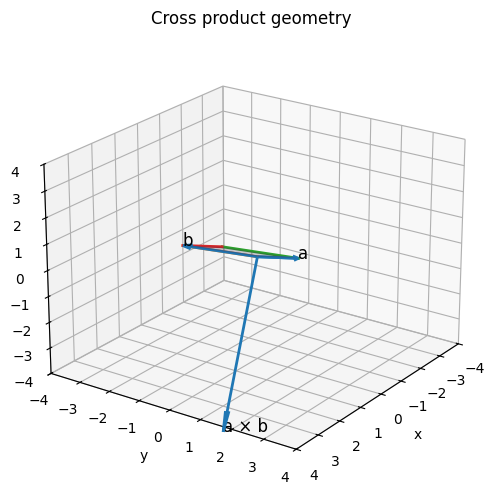

a = [1. 2. 1.]
b = [ 2. -1.  1.]
a x b = [ 3.  1. -5.]
|a x b| = 5.916079783099616


In [4]:
a = np.array([1, 2, 1], dtype=float)
b = np.array([2, -1, 1], dtype=float)
axb = np.cross(a, b)

fig, ax = make_3d_axes("Cross product geometry", lim=4)

draw_vector_3d(ax, a, label="a")
draw_vector_3d(ax, b, label="b")
draw_vector_3d(ax, axb, label="a × b")

O = np.zeros(3)
P1 = a
P2 = b
P3 = a + b
edges = [(O, P1), (O, P2), (P1, P3), (P2, P3)]
for p, q in edges:
    ax.plot([p[0], q[0]], [p[1], q[1]], [p[2], q[2]], linewidth=2)

U = np.array([[0, 1], [0, 1]])
V = np.array([[0, 0], [1, 1]])
X = U*a[0] + V*b[0]
Y = U*a[1] + V*b[1]
Z = U*a[2] + V*b[2]
ax.plot_surface(X, Y, Z, alpha=0.25)

plt.show()

print("a =", a)
print("b =", b)
print("a x b =", axb)
print("|a x b| =", norm(axb))

## 3. Orientation: $\mathbf a\times\mathbf b$ versus $\mathbf b\times\mathbf a$

The cross product is anti-commutative:

$$
\mathbf b\times\mathbf a=-(\mathbf a\times\mathbf b).
$$

Switching the order reverses the normal direction.

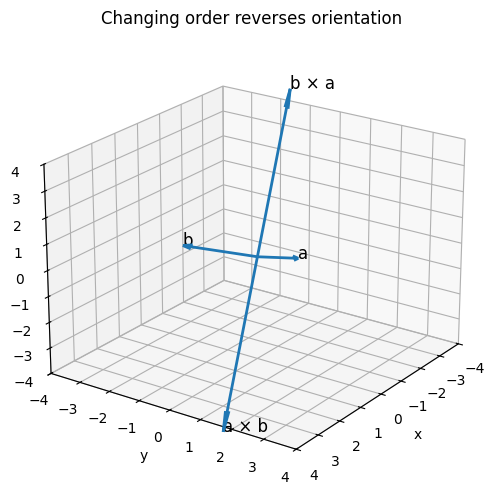

a x b = [ 3.  1. -5.]
b x a = [-3. -1.  5.]
Are they negatives? True


In [5]:
a = np.array([1, 2, 1], dtype=float)
b = np.array([2, -1, 1], dtype=float)

axb = np.cross(a, b)
bxa = np.cross(b, a)

fig, ax = make_3d_axes("Changing order reverses orientation", lim=4)
draw_vector_3d(ax, a, label="a")
draw_vector_3d(ax, b, label="b")
draw_vector_3d(ax, axb, label="a × b")
draw_vector_3d(ax, bxa, label="b × a")

plt.show()

print("a x b =", axb)
print("b x a =", bxa)
print("Are they negatives?", np.allclose(bxa, -axb))

## 4. Standard basis orientation

Let

$$
\mathbf i=\langle 1,0,0\rangle,\quad
\mathbf j=\langle 0,1,0\rangle,\quad
\mathbf k=\langle 0,0,1\rangle.
$$

The standard orientation is:

$$
\mathbf i\times\mathbf j=\mathbf k,\qquad
\mathbf j\times\mathbf k=\mathbf i,\qquad
\mathbf k\times\mathbf i=\mathbf j.
$$

In [6]:
i = np.array([1, 0, 0], dtype=float)
j = np.array([0, 1, 0], dtype=float)
k = np.array([0, 0, 1], dtype=float)

pairs = [
    ("i x j", i, j),
    ("j x k", j, k),
    ("k x i", k, i),
    ("j x i", j, i),
    ("k x j", k, j),
    ("i x k", i, k),
]

for name, u, v in pairs:
    print(f"{name:5s} = {np.cross(u, v)}")

i x j = [0. 0. 1.]
j x k = [1. 0. 0.]
k x i = [0. 1. 0.]
j x i = [ 0.  0. -1.]
k x j = [-1.  0.  0.]
i x k = [ 0. -1.  0.]


## 5. Area using the cross product

For two vectors $\mathbf a$ and $\mathbf b$,

$$
\text{Area of parallelogram}=|\mathbf a\times\mathbf b|.
$$

For the triangle with sides represented by $\mathbf a$ and $\mathbf b$,

$$
\text{Area of triangle}=\frac12|\mathbf a\times\mathbf b|.
$$

In [7]:
def parallelogram_area(a, b):
    return norm(np.cross(a, b))

def triangle_area_from_vectors(a, b):
    return 0.5 * parallelogram_area(a, b)

a = np.array([1, 2, 3], dtype=float)
b = np.array([3, 2, 1], dtype=float)

print("Area of parallelogram =", parallelogram_area(a, b))
print("Area of triangle =", triangle_area_from_vectors(a, b))

Area of parallelogram = 9.797958971132712
Area of triangle = 4.898979485566356


### Guided task 2: area of a triangle from three points

Let

$$
P=(1,0,2),\qquad Q=(3,1,4),\qquad R=(2,4,1).
$$

Compute the area of triangle $PQR$.

In [8]:
P = np.array([1, 0, 2], dtype=float)
Q = np.array([3, 1, 4], dtype=float)
R = np.array([2, 4, 1], dtype=float)

PQ = Q - P
PR = R - P

area = 0.5 * norm(np.cross(PQ, PR))

print("PQ =", PQ)
print("PR =", PR)
print("Area of triangle PQR =", area)

PQ = [2. 1. 2.]
PR = [ 1.  4. -1.]
Area of triangle PQR = 6.041522986797286


## 6. Cross products and plane equations

A plane through three non-collinear points $P$, $Q$, and $R$ has normal vector

$$
\mathbf n=(Q-P)\times(R-P).
$$

Then the plane equation is

$$
\mathbf n\cdot(\mathbf x-P)=0.
$$

Equivalently, if $\mathbf n=\langle A,B,C\rangle$ and $P=(x_0,y_0,z_0)$,

$$
A(x-x_0)+B(y-y_0)+C(z-z_0)=0.
$$

In [9]:
def plane_from_three_points(P, Q, R, tol=1e-12):
    P = np.asarray(P, dtype=float)
    Q = np.asarray(Q, dtype=float)
    R = np.asarray(R, dtype=float)
    n = np.cross(Q - P, R - P)
    if norm(n) < tol:
        raise ValueError("The three points appear to be collinear.")
    d = dot(n, P)
    return n, d

P = np.array([1, 0, 2], dtype=float)
Q = np.array([3, 1, 4], dtype=float)
R = np.array([2, 4, 1], dtype=float)

n, d = plane_from_three_points(P, Q, R)

print("normal vector n =", n)
print("plane equation: n dot <x,y,z> = d")
print("d =", d)

for name, point in [("P", P), ("Q", Q), ("R", R)]:
    print(name, "n dot point =", dot(n, point))

normal vector n = [-9.  4.  7.]
plane equation: n dot <x,y,z> = d
d = 5.0
P n dot point = 5.0
Q n dot point = 5.0
R n dot point = 5.0


### Visualize the plane through three points

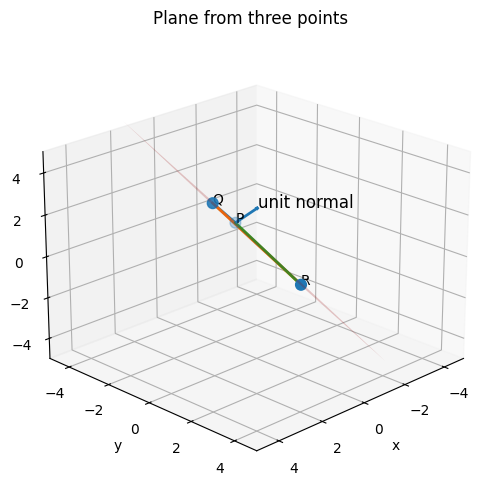

In [10]:
P = np.array([1, 0, 2], dtype=float)
Q = np.array([3, 1, 4], dtype=float)
R = np.array([2, 4, 1], dtype=float)
n, d = plane_from_three_points(P, Q, R)

fig, ax = make_3d_axes("Plane from three points", elev=22, azim=45, lim=5)

points = np.vstack([P, Q, R])
ax.scatter(points[:,0], points[:,1], points[:,2], s=60)
for label, p in zip(["P", "Q", "R"], [P, Q, R]):
    ax.text(p[0], p[1], p[2], label)

for A, B in [(P, Q), (Q, R), (R, P)]:
    ax.plot([A[0], B[0]], [A[1], B[1]], [A[2], B[2]], linewidth=2)

xx, yy = np.meshgrid(np.linspace(-1, 5, 15), np.linspace(-1, 5, 15))
if abs(n[2]) > 1e-12:
    zz = (d - n[0]*xx - n[1]*yy) / n[2]
    ax.plot_surface(xx, yy, zz, alpha=0.25)

draw_vector_3d(ax, n / norm(n), start=P, label="unit normal")

plt.show()

## 7. Scalar triple product and volume

The scalar triple product is

$$
\mathbf a\cdot(\mathbf b\times\mathbf c).
$$

It measures signed volume:

$$
\text{Volume of parallelepiped}
=
|\mathbf a\cdot(\mathbf b\times\mathbf c)|.
$$

If the scalar triple product is zero, then the three vectors are coplanar.

In [11]:
a = np.array([1, 0, 2], dtype=float)
b = np.array([2, 1, 0], dtype=float)
c = np.array([1, 3, 1], dtype=float)

signed_volume = scalar_triple(a, b, c)
volume = abs(signed_volume)

print("a dot (b x c) =", signed_volume)
print("Volume =", volume)

a dot (b x c) = 11.0
Volume = 11.0


### Guided task 3: test coplanarity

Determine whether

$$
\mathbf a=\langle 1,2,3\rangle,\quad
\mathbf b=\langle 2,4,6\rangle,\quad
\mathbf c=\langle 1,0,1\rangle
$$

are coplanar.

In [12]:
a = np.array([1, 2, 3], dtype=float)
b = np.array([2, 4, 6], dtype=float)
c = np.array([1, 0, 1], dtype=float)

stp = scalar_triple(a, b, c)

print("Scalar triple product =", stp)
print("Coplanar?", np.isclose(stp, 0))

Scalar triple product = 0.0
Coplanar? True


### Visualizing a parallelepiped

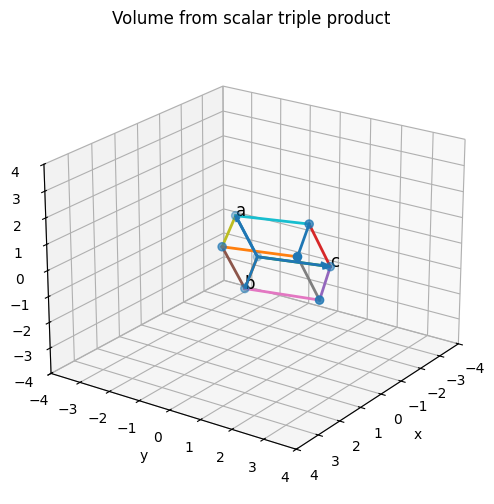

Volume = 11.0


In [13]:
def plot_parallelepiped(a, b, c, title="Parallelepiped"):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    c = np.asarray(c, dtype=float)

    fig, ax = make_3d_axes(title, lim=4)

    coeffs = [(s,t,u) for s in [0,1] for t in [0,1] for u in [0,1]]
    vdict = {coeff: coeff[0]*a + coeff[1]*b + coeff[2]*c for coeff in coeffs}
    vertices = np.array(list(vdict.values()))

    for coeff in coeffs:
        for idx in range(3):
            coeff2 = list(coeff)
            coeff2[idx] = 1 - coeff2[idx]
            coeff2 = tuple(coeff2)
            if coeff < coeff2:
                p = vdict[coeff]
                q = vdict[coeff2]
                ax.plot([p[0],q[0]], [p[1],q[1]], [p[2],q[2]], linewidth=2)

    draw_vector_3d(ax, a, label="a")
    draw_vector_3d(ax, b, label="b")
    draw_vector_3d(ax, c, label="c")
    ax.scatter(vertices[:,0], vertices[:,1], vertices[:,2], s=35)
    plt.show()

a = np.array([1, 0, 2], dtype=float)
b = np.array([2, 1, 0], dtype=float)
c = np.array([1, 3, 1], dtype=float)

plot_parallelepiped(a, b, c, title="Volume from scalar triple product")
print("Volume =", abs(scalar_triple(a, b, c)))

---

# Part II. Vector-valued functions and curves

A vector-valued function in space has the form

$$
\mathbf r(t)=\langle x(t),y(t),z(t)\rangle.
$$

You can think of $\mathbf r(t)$ as the position of a moving particle at time $t$.

The derivative

$$
\mathbf r'(t)=\langle x'(t),y'(t),z'(t)\rangle
$$

is the velocity vector, and the second derivative $\mathbf r''(t)$ is the acceleration vector.

## 8. Plotting a space curve: helix

A standard helix is

$$
\mathbf r(t)=\langle \cos t,\sin t,t\rangle.
$$

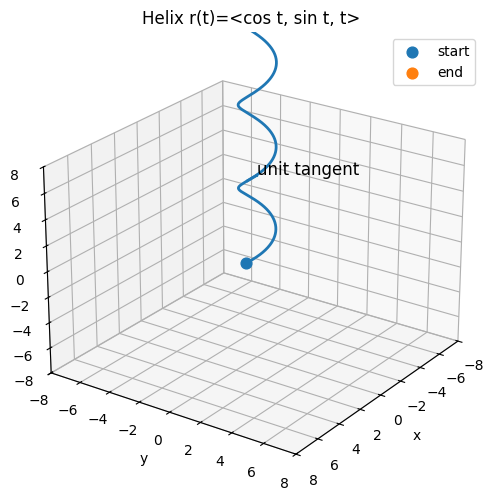

In [14]:
def helix(t):
    return np.column_stack([np.cos(t), np.sin(t), t])

t = np.linspace(0, 6*np.pi, 500)
R = helix(t)

fig, ax = make_3d_axes("Helix r(t)=<cos t, sin t, t>", elev=24, azim=35, lim=8)
ax.plot(R[:,0], R[:,1], R[:,2], linewidth=2)

ax.scatter(R[0,0], R[0,1], R[0,2], s=60, label="start")
ax.scatter(R[-1,0], R[-1,1], R[-1,2], s=60, label="end")

t0 = 2*np.pi
r0 = np.array([np.cos(t0), np.sin(t0), t0])
v0 = np.array([-np.sin(t0), np.cos(t0), 1.0])
draw_vector_3d(ax, unit(v0), start=r0, label="unit tangent")

ax.legend()
plt.show()

## 9. Velocity, speed, and acceleration

For

$$
\mathbf r(t)=\langle \cos t,\sin t,t\rangle,
$$

we have

$$
\mathbf v(t)=\mathbf r'(t)=\langle-\sin t,\cos t,1\rangle
$$

and

$$
\mathbf a(t)=\mathbf r''(t)=\langle-\cos t,-\sin t,0\rangle.
$$

The speed is $|\mathbf v(t)|$.

In [15]:
def r_helix(t):
    return np.array([np.cos(t), np.sin(t), t], dtype=float)

def v_helix(t):
    return np.array([-np.sin(t), np.cos(t), 1.0], dtype=float)

def acc_helix(t):
    return np.array([-np.cos(t), -np.sin(t), 0.0], dtype=float)

for t0 in [0, np.pi/2, np.pi, 2*np.pi]:
    r0 = r_helix(t0)
    v0 = v_helix(t0)
    a0 = acc_helix(t0)
    print(f"t = {t0:.3f}")
    print("  position     =", r0)
    print("  velocity     =", v0)
    print("  speed        =", norm(v0))
    print("  acceleration =", a0)
    print()

t = 0.000
  position     = [1. 0. 0.]
  velocity     = [-0.  1.  1.]
  speed        = 1.4142135623730951
  acceleration = [-1. -0.  0.]

t = 1.571
  position     = [0.     1.     1.5708]
  velocity     = [-1.  0.  1.]
  speed        = 1.4142135623730951
  acceleration = [-0. -1.  0.]

t = 3.142
  position     = [-1.       0.       3.14159]
  velocity     = [-0. -1.  1.]
  speed        = 1.4142135623730951
  acceleration = [ 1. -0.  0.]

t = 6.283
  position     = [ 1.      -0.       6.28319]
  velocity     = [0. 1. 1.]
  speed        = 1.4142135623730951
  acceleration = [-1.  0.  0.]



### Visualizing velocity and acceleration along the helix

Velocity is tangent to the curve. Acceleration points inward toward the axis of the helix.

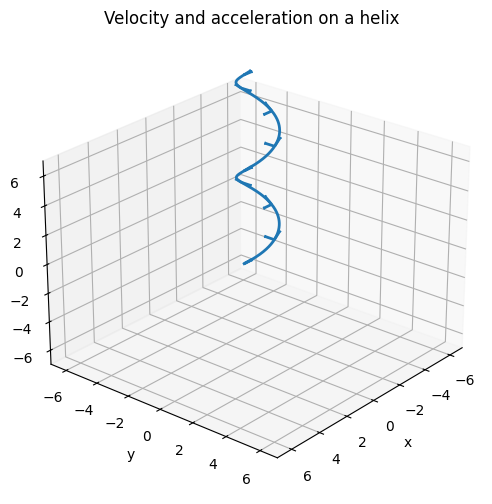

In [16]:
t = np.linspace(0, 4*np.pi, 400)
R = helix(t)

fig, ax = make_3d_axes("Velocity and acceleration on a helix", elev=25, azim=40, lim=7)
ax.plot(R[:,0], R[:,1], R[:,2], linewidth=2)

for t0 in np.linspace(0, 4*np.pi, 9):
    r0 = r_helix(t0)
    v0 = v_helix(t0)
    a0 = acc_helix(t0)
    draw_vector_3d(ax, 0.6*unit(v0), start=r0)
    draw_vector_3d(ax, 0.6*unit(a0), start=r0)

plt.show()

## 10. Numerical derivatives from sampled position data

In applications, we often do not know a formula for $\mathbf r(t)$. Instead, we have sampled points. The following function uses finite differences to estimate derivatives.

In [17]:
def numerical_derivative(values, t):
    values = np.asarray(values, dtype=float)
    t = np.asarray(t, dtype=float)
    return np.gradient(values, t, axis=0, edge_order=2)

t = np.linspace(0, 6*np.pi, 200)
R = helix(t)

V_num = numerical_derivative(R, t)
A_num = numerical_derivative(V_num, t)
speed_num = np.linalg.norm(V_num, axis=1)

print("First few numerical velocities:")
print(V_num[:5])

print("\nMean numerical speed:", speed_num.mean())
print("Expected exact speed for helix:", np.sqrt(2))

First few numerical velocities:
[[-0.00021  1.00298  1.     ]
 [-0.09444  0.99403  1.     ]
 [-0.18803  0.98064  1.     ]
 [-0.27994  0.95846  1.     ]
 [-0.36933  0.92769  1.     ]]

Mean numerical speed: 1.4131887169995918
Expected exact speed for helix: 1.4142135623730951


### Plot numerical speed

For this helix, the exact speed is constant:

$$
|\mathbf r'(t)|=\sqrt{2}.
$$

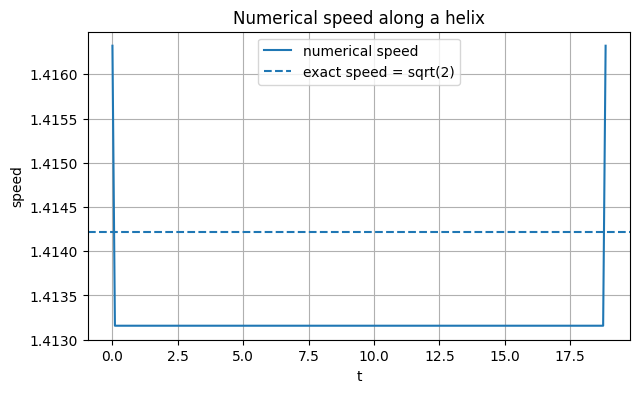

In [18]:
plt.figure(figsize=(7, 4))
plt.plot(t, speed_num, label="numerical speed")
plt.axhline(np.sqrt(2), linestyle="--", label="exact speed = sqrt(2)")
plt.xlabel("t")
plt.ylabel("speed")
plt.title("Numerical speed along a helix")
plt.legend()
plt.grid(True)
plt.show()

## 11. Arc length

The arc length of a smooth curve $\mathbf r(t)$ from $t=a$ to $t=b$ is

$$
L=\int_a^b |\mathbf r'(t)|\,dt.
$$

For sampled data, we can approximate this two ways:

1. integrate speed numerically;
2. sum distances between consecutive sampled points.

The second method is the polygonal approximation.

In [19]:
def cumulative_trapezoid(y, x):
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    increments = 0.5 * (y[1:] + y[:-1]) * np.diff(x)
    return np.concatenate([[0.0], np.cumsum(increments)])

def polygonal_arc_length(points):
    points = np.asarray(points, dtype=float)
    diffs = np.diff(points, axis=0)
    return float(np.sum(np.linalg.norm(diffs, axis=1)))

t = np.linspace(0, 6*np.pi, 1000)
R = helix(t)
V = numerical_derivative(R, t)
speed = np.linalg.norm(V, axis=1)

S = cumulative_trapezoid(speed, t)
L_speed = S[-1]
L_polygon = polygonal_arc_length(R)
L_exact = np.sqrt(2) * (t[-1] - t[0])

print("Arc length by integrating numerical speed =", L_speed)
print("Arc length by polygonal approximation       =", L_polygon)
print("Exact arc length                            =", L_exact)
print("Absolute errors:")
print("  speed integral:", abs(L_speed - L_exact))
print("  polygonal     :", abs(L_polygon - L_exact))

Arc length by integrating numerical speed = 26.656509157675497
Arc length by polygonal approximation       = 26.657099912588592
Exact arc length                            = 26.657297628950197
Absolute errors:
  speed integral: 0.0007884712746992761
  polygonal     : 0.00019771636160470507


### Arc length function

The arc length function is

$$
s(t)=\int_a^t|\mathbf r'(u)|\,du.
$$

For a constant-speed curve, $s(t)$ is linear in $t$.

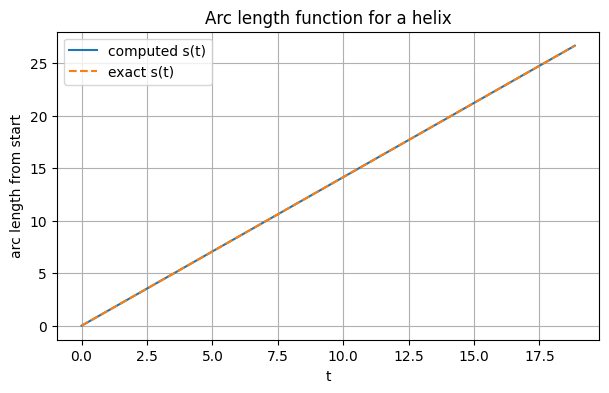

In [20]:
plt.figure(figsize=(7, 4))
plt.plot(t, S, label="computed s(t)")
plt.plot(t, np.sqrt(2)*(t - t[0]), linestyle="--", label="exact s(t)")
plt.xlabel("t")
plt.ylabel("arc length from start")
plt.title("Arc length function for a helix")
plt.legend()
plt.grid(True)
plt.show()

## 12. Arc length parameterization of a helix

For

$$
\mathbf r(t)=\langle \cos t,\sin t,t\rangle,
$$

speed is $\sqrt{2}$, so

$$
s=\sqrt{2}\,t,\qquad t=\frac{s}{\sqrt{2}}.
$$

Therefore, the arc length parameterization is

$$
\mathbf r(s)
=
\left\langle
\cos\left(\frac{s}{\sqrt 2}\right),
\sin\left(\frac{s}{\sqrt 2}\right),
\frac{s}{\sqrt 2}
\right\rangle.
$$

Mean speed with respect to arc length parameter: 0.9998825316353034
Min and max speed: 0.999881105134296 1.0002377303719756


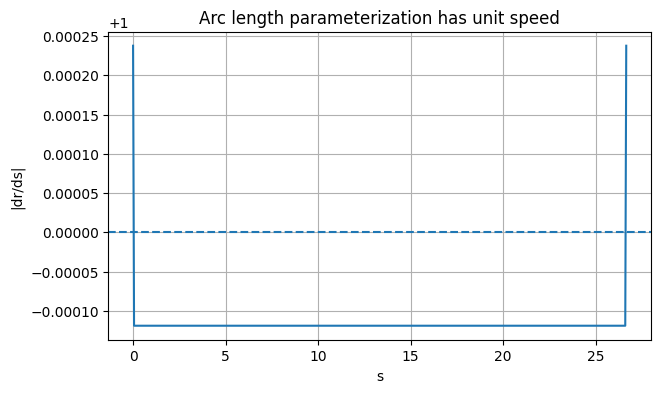

In [21]:
def helix_by_arc_length(s):
    t = s / np.sqrt(2)
    return np.column_stack([np.cos(t), np.sin(t), t])

s = np.linspace(0, np.sqrt(2)*6*np.pi, 500)
Rs = helix_by_arc_length(s)

dRds = numerical_derivative(Rs, s)
speed_s = np.linalg.norm(dRds, axis=1)

print("Mean speed with respect to arc length parameter:", speed_s.mean())
print("Min and max speed:", speed_s.min(), speed_s.max())

plt.figure(figsize=(7, 4))
plt.plot(s, speed_s)
plt.axhline(1, linestyle="--")
plt.xlabel("s")
plt.ylabel("|dr/ds|")
plt.title("Arc length parameterization has unit speed")
plt.grid(True)
plt.show()

## 13. Unit tangent vector

The unit tangent vector is

$$
\mathbf T(t)=\frac{\mathbf r'(t)}{|\mathbf r'(t)|}.
$$

For sampled data, we estimate velocity numerically and normalize.

In [22]:
t = np.linspace(0, 4*np.pi, 300)
R = helix(t)
V = numerical_derivative(R, t)
T = V / np.linalg.norm(V, axis=1)[:, None]

print("First five unit tangent vectors:")
print(T[:5])

print("\nNorms of first five unit tangents:")
print(np.linalg.norm(T[:5], axis=1))

First five unit tangent vectors:


[[-0.00001  0.70731  0.7069 ]
 [-0.02971  0.70638  0.70721]
 [-0.05936  0.70451  0.70721]
 [-0.08891  0.70139  0.70721]
 [-0.1183   0.69704  0.70721]]

Norms of first five unit tangents:
[1. 1. 1. 1. 1.]


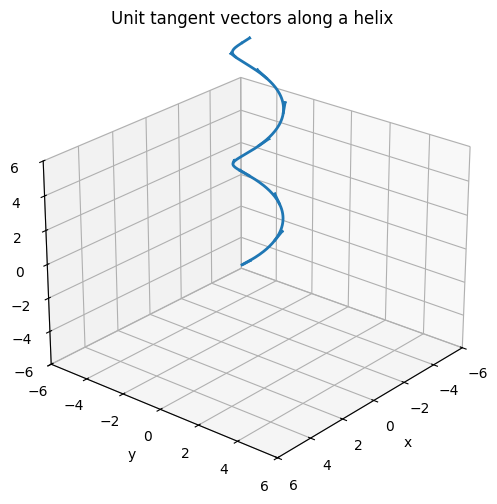

In [23]:
fig, ax = make_3d_axes("Unit tangent vectors along a helix", elev=25, azim=40, lim=6)
ax.plot(R[:,0], R[:,1], R[:,2], linewidth=2)

for idx in np.linspace(0, len(t)-1, 10, dtype=int):
    draw_vector_3d(ax, 0.65*T[idx], start=R[idx])

plt.show()

## 14. Curvature

Curvature measures how fast the unit tangent direction changes with respect to arc length:

$$
\kappa=\left|\frac{d\mathbf T}{ds}\right|.
$$

For a regular curve, an equivalent formula is

$$
\kappa(t)=
\frac{|\mathbf r'(t)\times \mathbf r''(t)|}{|\mathbf r'(t)|^3}.
$$

This formula is very convenient for computation.

In [24]:
def curvature_from_va(V, A, tol=1e-12):
    V = np.asarray(V, dtype=float)
    A = np.asarray(A, dtype=float)
    cross_va = np.cross(V, A)
    numerator = np.linalg.norm(cross_va, axis=-1)
    denominator = np.linalg.norm(V, axis=-1)**3
    return numerator / np.maximum(denominator, tol)

t = np.linspace(0, 6*np.pi, 500)
V_exact = np.column_stack([-np.sin(t), np.cos(t), np.ones_like(t)])
A_exact = np.column_stack([-np.cos(t), -np.sin(t), np.zeros_like(t)])

kappa = curvature_from_va(V_exact, A_exact)

print("Mean curvature =", kappa.mean())
print("Expected curvature for this helix = 1/2")
print("Min, max curvature =", kappa.min(), kappa.max())

Mean curvature = 0.5
Expected curvature for this helix = 1/2
Min, max curvature = 0.49999999999999983 0.5000000000000001


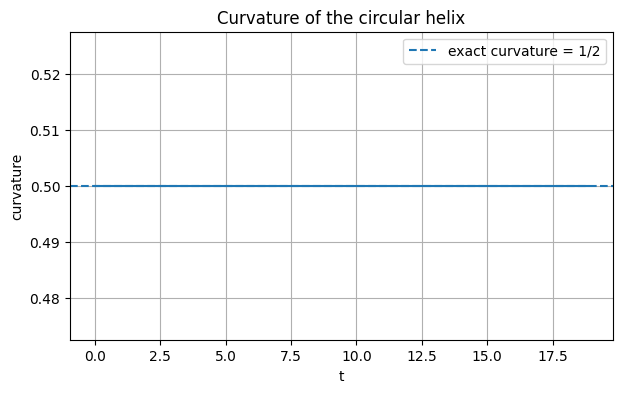

In [25]:
plt.figure(figsize=(7, 4))
plt.plot(t, kappa)
plt.axhline(0.5, linestyle="--", label="exact curvature = 1/2")
plt.xlabel("t")
plt.ylabel("curvature")
plt.title("Curvature of the circular helix")
plt.legend()
plt.grid(True)
plt.show()

## 15. Curvature of circles

For a circle of radius $a$,

$$
\kappa=\frac{1}{a}.
$$

The smaller the circle, the more sharply it curves.

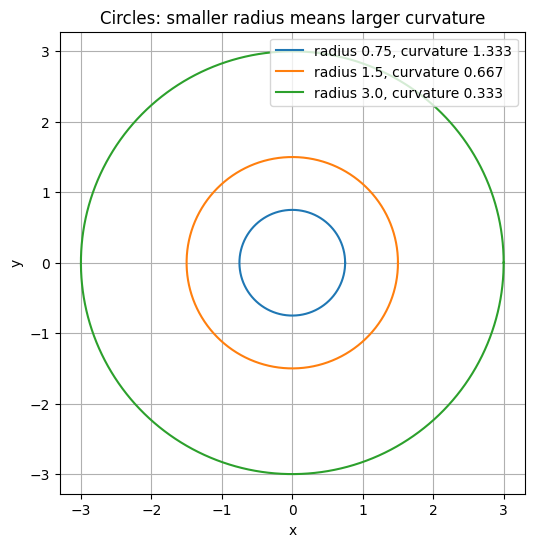

In [26]:
def circle_points(radius, n=400):
    t = np.linspace(0, 2*np.pi, n)
    return t, np.column_stack([radius*np.cos(t), radius*np.sin(t), np.zeros_like(t)])

radii = [0.75, 1.5, 3.0]

plt.figure(figsize=(6, 6))
for radius in radii:
    t_circle, C = circle_points(radius)
    plt.plot(C[:,0], C[:,1], label=f"radius {radius}, curvature {1/radius:.3f}")
plt.axis("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Circles: smaller radius means larger curvature")
plt.legend()
plt.grid(True)
plt.show()

### Numerical curvature check for circles

In [27]:
for radius in radii:
    t_circle, C = circle_points(radius, n=1000)
    V = numerical_derivative(C, t_circle)
    A = numerical_derivative(V, t_circle)
    kappa_num = curvature_from_va(V, A)
    interior = slice(5, -5)
    print(f"radius = {radius}")
    print("  mean numerical curvature:", kappa_num[interior].mean())
    print("  exact curvature:", 1/radius)

radius = 0.75
  mean numerical curvature: 1.3333333333333348
  exact curvature: 1.3333333333333333
radius = 1.5
  mean numerical curvature: 0.6666666666666674
  exact curvature: 0.6666666666666666
radius = 3.0
  mean numerical curvature: 0.3333333333333337
  exact curvature: 0.3333333333333333


## 16. Speed minimization

Consider the curve

$$
\mathbf r(t)=\langle t^2+1,\;3t,\;t^2-4t\rangle.
$$

Its velocity is

$$
\mathbf r'(t)=\langle 2t,\;3,\;2t-4\rangle.
$$

We can find when speed is minimized numerically by evaluating speed on a grid.

In [28]:
def r_speed_example(t):
    t = np.asarray(t)
    return np.column_stack([t**2 + 1, 3*t, t**2 - 4*t])

def v_speed_example(t):
    t = np.asarray(t)
    return np.column_stack([2*t, 3*np.ones_like(t), 2*t - 4])

t = np.linspace(-2, 4, 800)
V = v_speed_example(t)
speed = np.linalg.norm(V, axis=1)

idx_min = np.argmin(speed)
t_min = t[idx_min]

print("Approximate t where speed is minimized:", t_min)
print("Minimum speed:", speed[idx_min])
print("Expected exact t = 1")

Approximate t where speed is minimized: 0.9962453066332917
Minimum speed: 4.123119302394514
Expected exact t = 1


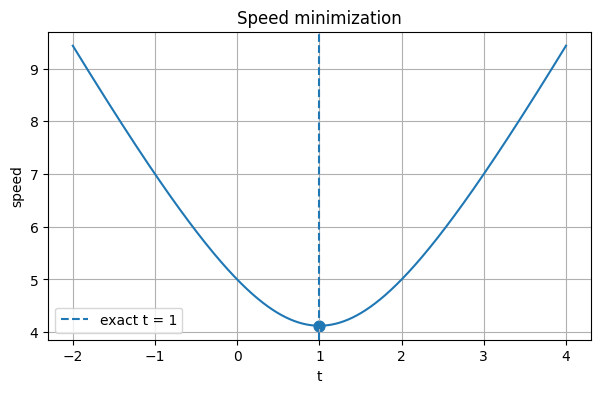

In [29]:
plt.figure(figsize=(7, 4))
plt.plot(t, speed)
plt.scatter([t_min], [speed[idx_min]], s=60)
plt.axvline(1, linestyle="--", label="exact t = 1")
plt.xlabel("t")
plt.ylabel("speed")
plt.title("Speed minimization")
plt.legend()
plt.grid(True)
plt.show()

### Why is the minimum at $t=1$?

It is usually easier to minimize speed squared:

$$
|\mathbf r'(t)|^2=(2t)^2+3^2+(2t-4)^2.
$$

This is a quadratic function of $t$.

In [30]:
speed_squared = speed**2

coeffs = np.polyfit(t, speed_squared, deg=2)
A, B, C0 = coeffs
t_vertex = -B/(2*A)

print("Fitted quadratic coefficients:", coeffs)
print("Vertex from fitted quadratic:", t_vertex)

Fitted quadratic coefficients: [  8. -16.  25.]
Vertex from fitted quadratic: 0.9999999999999994


---

# Part III. Modern viewpoint: trajectories in optimization and data

A sequence of points can be interpreted as a curve.

Examples:
- a robot moving through space;
- a particle trajectory;
- an aircraft path;
- a time series of feature vectors;
- an optimization path in parameter space.

In machine learning, gradient descent creates a trajectory

$$
\theta_0,\theta_1,\theta_2,\ldots
$$

in parameter space.

## 17. Gradient descent as a curve in parameter space

Consider the loss function

$$
L(x,y)=x^2+4y^2.
$$

The gradient is

$$
\nabla L(x,y)=\langle 2x,8y\rangle.
$$

Gradient descent updates

$$
\mathbf p_{k+1}=\mathbf p_k-\eta \nabla L(\mathbf p_k).
$$

In [31]:
def loss(p):
    x, y = p
    return x**2 + 4*y**2

def grad_loss(p):
    x, y = p
    return np.array([2*x, 8*y], dtype=float)

eta = 0.08
p = np.array([3.5, 2.0], dtype=float)
path = [p.copy()]

for k in range(60):
    p = p - eta * grad_loss(p)
    path.append(p.copy())

path = np.array(path)

print("Initial point:", path[0])
print("Final point:", path[-1])
print("Final loss:", loss(path[-1]))

Initial point: [3.5 2. ]
Final point: [0.0001 0.    ]
Final loss: 1.0038074535750045e-08


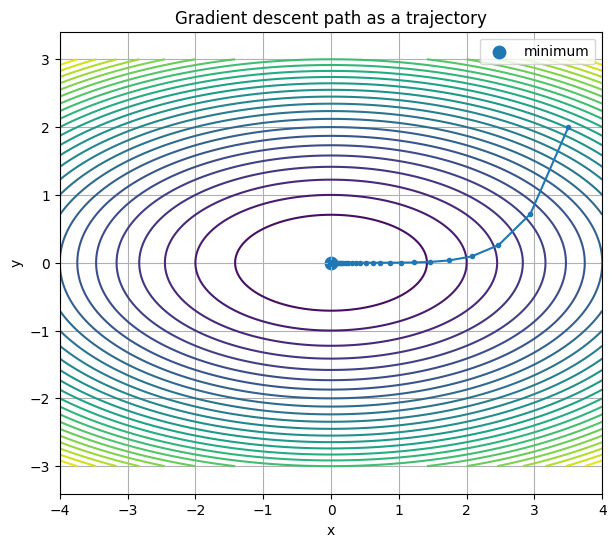

In [32]:
x = np.linspace(-4, 4, 300)
y = np.linspace(-3, 3, 300)
X, Y = np.meshgrid(x, y)
Z = X**2 + 4*Y**2

plt.figure(figsize=(7, 6))
plt.contour(X, Y, Z, levels=25)
plt.plot(path[:,0], path[:,1], marker="o", markersize=3)
plt.scatter([0], [0], s=80, label="minimum")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Gradient descent path as a trajectory")
plt.axis("equal")
plt.legend()
plt.grid(True)
plt.show()

### Speed along the optimization path

Even though gradient descent is discrete, we can treat the path as sampled data and approximate step speeds.

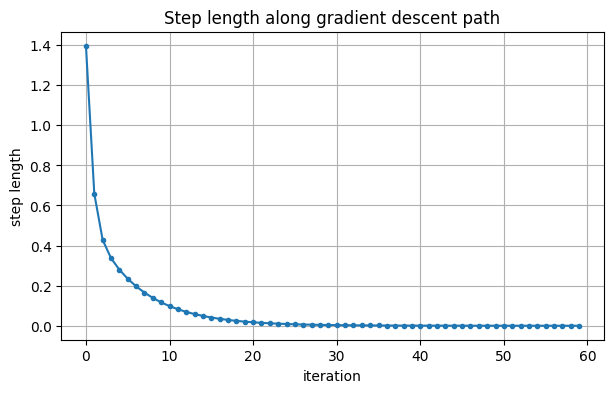

Total path length traveled: 4.564850719488415
Straight-line distance from start to final point: 4.0310418850088094


In [33]:
steps = np.diff(path, axis=0)
step_lengths = np.linalg.norm(steps, axis=1)

plt.figure(figsize=(7, 4))
plt.plot(step_lengths, marker="o", markersize=3)
plt.xlabel("iteration")
plt.ylabel("step length")
plt.title("Step length along gradient descent path")
plt.grid(True)
plt.show()

print("Total path length traveled:", step_lengths.sum())
print("Straight-line distance from start to final point:", norm(path[0] - path[-1]))

## 18. Data stream example: a curve in feature space

Suppose each observation has three features:

$$
(x(t),y(t),z(t)).
$$

As time changes, the data point moves through feature space. This is a vector-valued function.

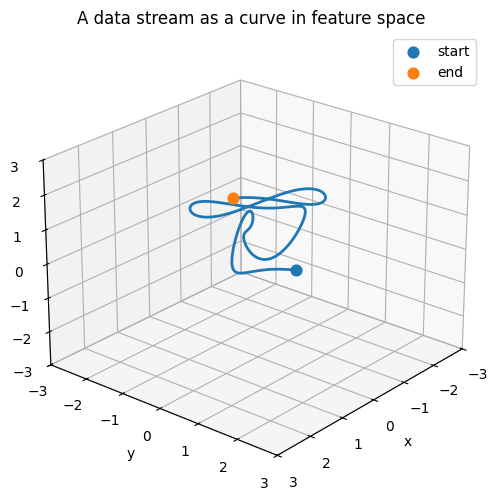

In [34]:
t = np.linspace(0, 20, 500)
x = np.sin(t)
y = np.cos(0.7*t)
z = 0.1*t + 0.2*np.sin(2*t)
data_curve = np.column_stack([x, y, z])

fig, ax = make_3d_axes("A data stream as a curve in feature space", elev=24, azim=40, lim=3)
ax.plot(data_curve[:,0], data_curve[:,1], data_curve[:,2], linewidth=2)
ax.scatter(data_curve[0,0], data_curve[0,1], data_curve[0,2], s=60, label="start")
ax.scatter(data_curve[-1,0], data_curve[-1,1], data_curve[-1,2], s=60, label="end")
ax.legend()
plt.show()

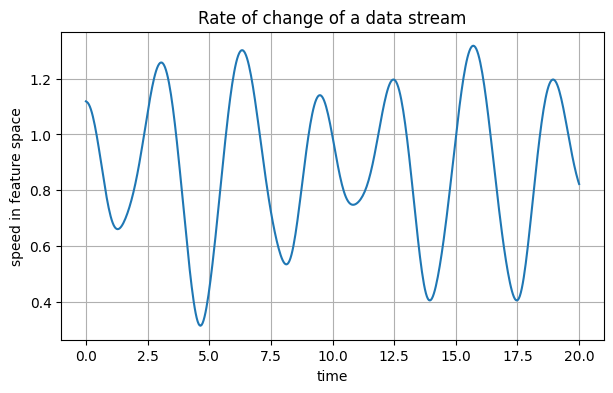

Average feature-space speed: 0.878198444524161
Maximum feature-space speed: 1.3186673723957767


In [35]:
V_data = numerical_derivative(data_curve, t)
speed_data = np.linalg.norm(V_data, axis=1)

plt.figure(figsize=(7, 4))
plt.plot(t, speed_data)
plt.xlabel("time")
plt.ylabel("speed in feature space")
plt.title("Rate of change of a data stream")
plt.grid(True)
plt.show()

print("Average feature-space speed:", speed_data.mean())
print("Maximum feature-space speed:", speed_data.max())

---

# Part IV. Chapter project: tracking motion from sampled data

In this project, we simulate position measurements of a moving object in space. Then we reconstruct:

1. velocity,
2. speed,
3. acceleration,
4. arc length traveled,
5. curvature.

We use a noisy trajectory to mimic real data.

## 19. Generate synthetic motion data

The true path is a perturbed helix:

$$
\mathbf r(t)
=
\langle
(1+0.2\cos 3t)\cos t,\;
(1+0.2\cos 3t)\sin t,\;
0.25t+0.15\sin 2t
\rangle.
$$

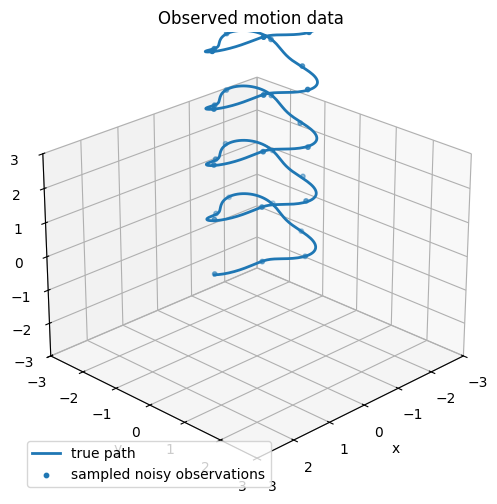

In [36]:
rng = np.random.default_rng(2321)

def true_motion(t):
    t = np.asarray(t)
    radius = 1 + 0.2*np.cos(3*t)
    x = radius*np.cos(t)
    y = radius*np.sin(t)
    z = 0.25*t + 0.15*np.sin(2*t)
    return np.column_stack([x, y, z])

t = np.linspace(0, 10*np.pi, 700)
R_true = true_motion(t)

noise_level = 0.015
R_obs = R_true + noise_level*rng.normal(size=R_true.shape)

fig, ax = make_3d_axes("Observed motion data", elev=25, azim=45, lim=3)
ax.plot(R_true[:,0], R_true[:,1], R_true[:,2], linewidth=2, label="true path")
ax.scatter(R_obs[::20,0], R_obs[::20,1], R_obs[::20,2], s=10, label="sampled noisy observations")
ax.legend()
plt.show()

## 20. Estimate velocity and speed

Finite differences can be noisy. We first compute derivatives directly, then compare with a smoothed version of the observed path.

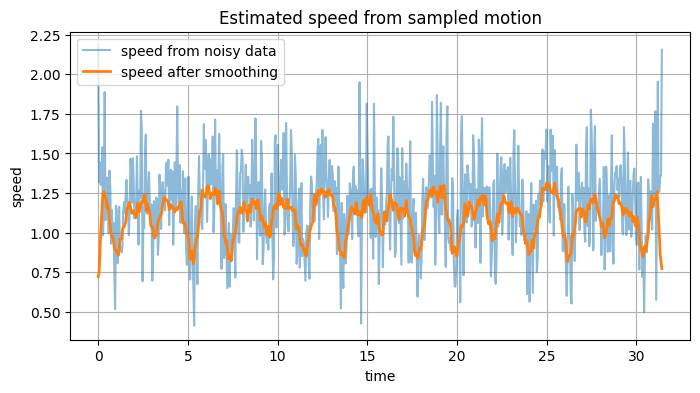

Mean speed after smoothing: 1.0993914734489103
Max speed after smoothing: 1.3156991560822127


In [37]:
def moving_average_curve(points, window=9):
    if window % 2 == 0:
        raise ValueError("window must be odd.")
    points = np.asarray(points, dtype=float)
    pad = window // 2
    padded = np.pad(points, ((pad, pad), (0, 0)), mode="edge")
    kernel = np.ones(window) / window
    smoothed_cols = []
    for j in range(points.shape[1]):
        smoothed_cols.append(np.convolve(padded[:, j], kernel, mode="valid"))
    return np.column_stack(smoothed_cols)

R_smooth = moving_average_curve(R_obs, window=11)

V_obs = numerical_derivative(R_obs, t)
V_smooth = numerical_derivative(R_smooth, t)

speed_obs = np.linalg.norm(V_obs, axis=1)
speed_smooth = np.linalg.norm(V_smooth, axis=1)

plt.figure(figsize=(8, 4))
plt.plot(t, speed_obs, alpha=0.5, label="speed from noisy data")
plt.plot(t, speed_smooth, linewidth=2, label="speed after smoothing")
plt.xlabel("time")
plt.ylabel("speed")
plt.title("Estimated speed from sampled motion")
plt.legend()
plt.grid(True)
plt.show()

print("Mean speed after smoothing:", speed_smooth.mean())
print("Max speed after smoothing:", speed_smooth.max())

## 21. Estimate total distance traveled

Total distance is approximated by polygonal arc length.

In [38]:
length_obs = polygonal_arc_length(R_obs)
length_smooth = polygonal_arc_length(R_smooth)
length_true = polygonal_arc_length(R_true)

print("Distance from noisy observations:", length_obs)
print("Distance from smoothed path:      ", length_smooth)
print("Distance from true path:          ", length_true)

Distance from noisy observations: 41.725555336600465
Distance from smoothed path:       34.59869694327251
Distance from true path:           35.60319448446323


## 22. Curvature from sampled data

Curvature depends on second derivatives, so it is more sensitive to noise than speed. Smoothing matters.

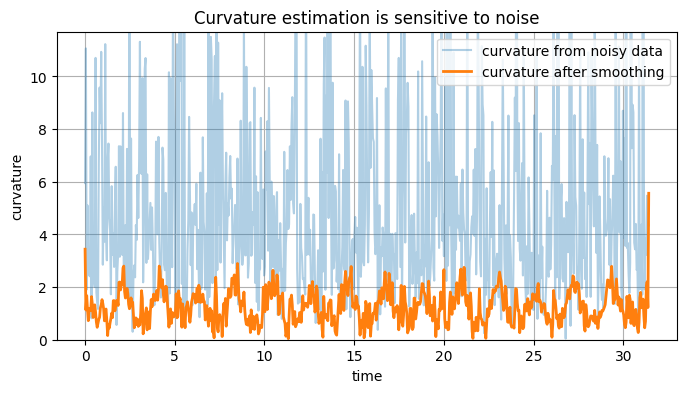

Mean smoothed curvature: 1.2645788858694467
Median smoothed curvature: 1.2149390378611142


In [39]:
A_obs = numerical_derivative(V_obs, t)
A_smooth = numerical_derivative(V_smooth, t)

curv_obs = curvature_from_va(V_obs, A_obs)
curv_smooth = curvature_from_va(V_smooth, A_smooth)

plt.figure(figsize=(8, 4))
plt.plot(t, curv_obs, alpha=0.35, label="curvature from noisy data")
plt.plot(t, curv_smooth, linewidth=2, label="curvature after smoothing")
plt.ylim(0, np.percentile(curv_obs, 95))
plt.xlabel("time")
plt.ylabel("curvature")
plt.title("Curvature estimation is sensitive to noise")
plt.legend()
plt.grid(True)
plt.show()

print("Mean smoothed curvature:", curv_smooth.mean())
print("Median smoothed curvature:", np.median(curv_smooth))

## 23. Identify high-curvature times

The following cell marks times when curvature is in the top 5 percent.

95th percentile curvature threshold: 2.2302300450548675
Number of high-curvature samples: 35


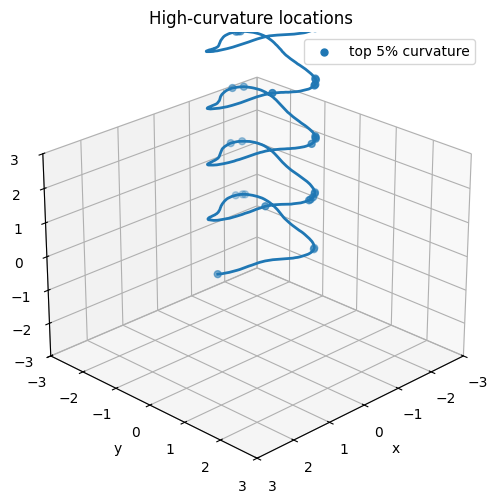

In [40]:
threshold = np.percentile(curv_smooth, 95)
high_curv = curv_smooth >= threshold

print("95th percentile curvature threshold:", threshold)
print("Number of high-curvature samples:", high_curv.sum())

fig, ax = make_3d_axes("High-curvature locations", elev=25, azim=45, lim=3)
ax.plot(R_smooth[:,0], R_smooth[:,1], R_smooth[:,2], linewidth=2)
ax.scatter(R_smooth[high_curv,0], R_smooth[high_curv,1], R_smooth[high_curv,2],
           s=25, label="top 5% curvature")
ax.legend()
plt.show()

## 24. Project questions

Answer these in a markdown cell below or in a separate submission.

1. Why does noise affect acceleration and curvature more strongly than position?
2. Why can total distance from noisy observations be larger than the true distance?
3. How does the smoothing window change the estimated speed and curvature?
4. Find a time where curvature is large. What is happening geometrically at that location?
5. Explain how this project connects to tracking a robot, animal, aircraft, or optimization path.

Window: 21
Estimated distance: 32.58659213728855
Mean speed: 1.0359896814355822
Mean curvature: 1.0735774682417145


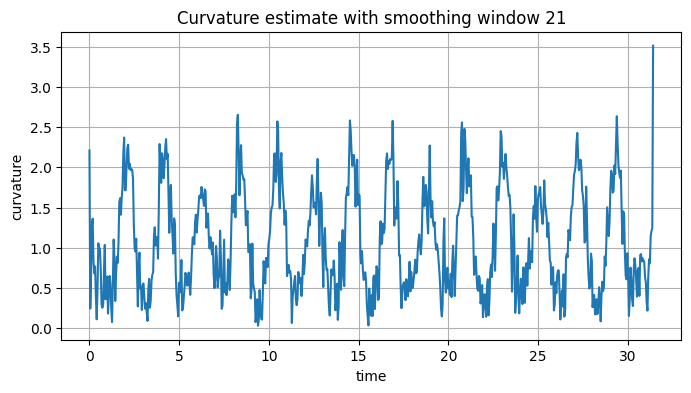

In [41]:
window = 21
R_test = moving_average_curve(R_obs, window=window)
V_test = numerical_derivative(R_test, t)
A_test = numerical_derivative(V_test, t)
speed_test = np.linalg.norm(V_test, axis=1)
curv_test = curvature_from_va(V_test, A_test)

print("Window:", window)
print("Estimated distance:", polygonal_arc_length(R_test))
print("Mean speed:", speed_test.mean())
print("Mean curvature:", curv_test.mean())

plt.figure(figsize=(8, 4))
plt.plot(t, curv_test)
plt.xlabel("time")
plt.ylabel("curvature")
plt.title(f"Curvature estimate with smoothing window {window}")
plt.grid(True)
plt.show()

---

# Part V. Additional exercises

These are designed for independent practice. Try them before looking at the reference cells.

## Exercise A. Cross product and area

Let

$$
\mathbf a=\langle 2,1,-1\rangle,\qquad
\mathbf b=\langle -1,3,2\rangle.
$$

1. Compute $\mathbf a\times\mathbf b$.
2. Verify that it is perpendicular to both $\mathbf a$ and $\mathbf b$.
3. Compute the area of the parallelogram spanned by $\mathbf a$ and $\mathbf b$.
4. Compute the area of the triangle spanned by $\mathbf a$ and $\mathbf b$.

In [42]:
# Exercise A workspace

a = np.array([2, 1, -1], dtype=float)
b = np.array([-1, 3, 2], dtype=float)

# Your code here

### Reference solution for Exercise A

In [43]:
a = np.array([2, 1, -1], dtype=float)
b = np.array([-1, 3, 2], dtype=float)

axb = np.cross(a, b)

print("a x b =", axb)
print("dot with a =", dot(axb, a))
print("dot with b =", dot(axb, b))
print("parallelogram area =", norm(axb))
print("triangle area =", 0.5*norm(axb))

a x b = [ 5. -3.  7.]
dot with a = 0.0
dot with b = 0.0
parallelogram area = 9.1104335791443
triangle area = 4.55521678957215


## Exercise B. Plane through three points

Let

$$
P=(0,1,2),\quad Q=(2,0,1),\quad R=(1,3,0).
$$

Find an equation of the plane through $P$, $Q$, and $R$.

In [44]:
# Exercise B workspace

P = np.array([0, 1, 2], dtype=float)
Q = np.array([2, 0, 1], dtype=float)
R = np.array([1, 3, 0], dtype=float)

# Your code here

### Reference solution for Exercise B

In [45]:
P = np.array([0, 1, 2], dtype=float)
Q = np.array([2, 0, 1], dtype=float)
R = np.array([1, 3, 0], dtype=float)

n, d = plane_from_three_points(P, Q, R)

print("normal vector n =", n)
print("plane equation: n dot <x,y,z> = d")
print("d =", d)
print("Expanded form:")
print(f"{n[0]:.0f} x + {n[1]:.0f} y + {n[2]:.0f} z = {d:.0f}")

normal vector n = [4. 3. 5.]
plane equation: n dot <x,y,z> = d
d = 13.0
Expanded form:
4 x + 3 y + 5 z = 13


## Exercise C. Scalar triple product

Let

$$
\mathbf a=\langle 1,1,0\rangle,\quad
\mathbf b=\langle 0,2,1\rangle,\quad
\mathbf c=\langle 3,0,2\rangle.
$$

Compute the volume of the parallelepiped spanned by $\mathbf a,\mathbf b,\mathbf c$.

In [46]:
# Exercise C workspace

a = np.array([1, 1, 0], dtype=float)
b = np.array([0, 2, 1], dtype=float)
c = np.array([3, 0, 2], dtype=float)

# Your code here

### Reference solution for Exercise C

In [47]:
a = np.array([1, 1, 0], dtype=float)
b = np.array([0, 2, 1], dtype=float)
c = np.array([3, 0, 2], dtype=float)

stp = scalar_triple(a, b, c)

print("signed volume =", stp)
print("volume =", abs(stp))

signed volume = 7.0
volume = 7.0


## Exercise D. Motion on a curve

Let

$$
\mathbf r(t)=\langle t,\;t^2,\;\sin t\rangle,\qquad 0\le t\le 4.
$$

1. Plot the curve.
2. Estimate velocity and speed numerically.
3. Plot speed as a function of $t$.
4. Estimate total distance traveled.

In [48]:
# Exercise D workspace

t = np.linspace(0, 4, 300)
R = np.column_stack([t, t**2, np.sin(t)])

# Your code here

### Reference solution for Exercise D

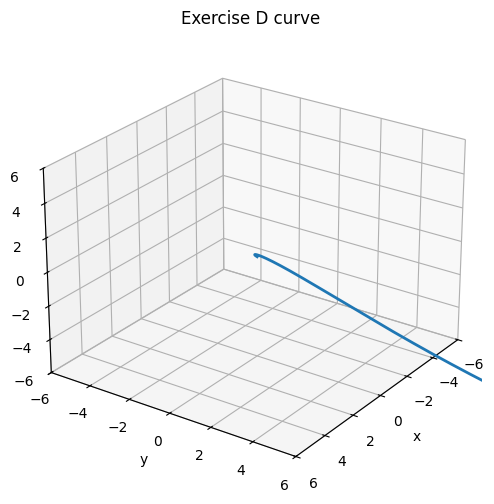

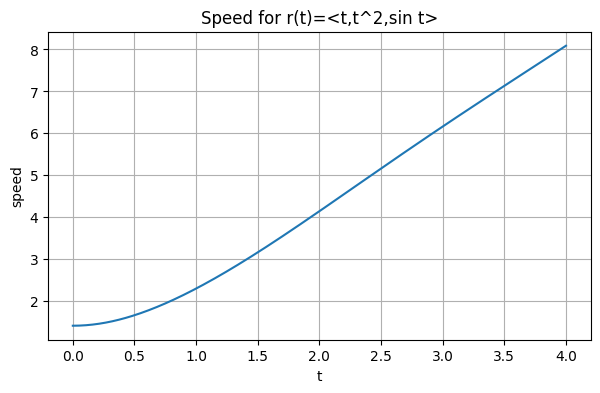

Estimated distance traveled: 17.200344290582567


In [49]:
t = np.linspace(0, 4, 300)
R = np.column_stack([t, t**2, np.sin(t)])

fig, ax = make_3d_axes("Exercise D curve", elev=25, azim=35, lim=6)
ax.plot(R[:,0], R[:,1], R[:,2], linewidth=2)
plt.show()

V = numerical_derivative(R, t)
speed = np.linalg.norm(V, axis=1)

plt.figure(figsize=(7, 4))
plt.plot(t, speed)
plt.xlabel("t")
plt.ylabel("speed")
plt.title("Speed for r(t)=<t,t^2,sin t>")
plt.grid(True)
plt.show()

print("Estimated distance traveled:", polygonal_arc_length(R))

## Exercise E. Curvature comparison

Compare the curvature of the following curves:

$$
\mathbf r_1(t)=\langle \cos t,\sin t,0\rangle
$$

and

$$
\mathbf r_2(t)=\langle 3\cos t,3\sin t,0\rangle.
$$

Which one curves more sharply?

In [50]:
# Exercise E workspace

t = np.linspace(0, 2*np.pi, 500)

# Your code here

### Reference solution for Exercise E

unit circle
  mean curvature: 1.0000000000000016
radius 3 circle
  mean curvature: 0.3333333333333337


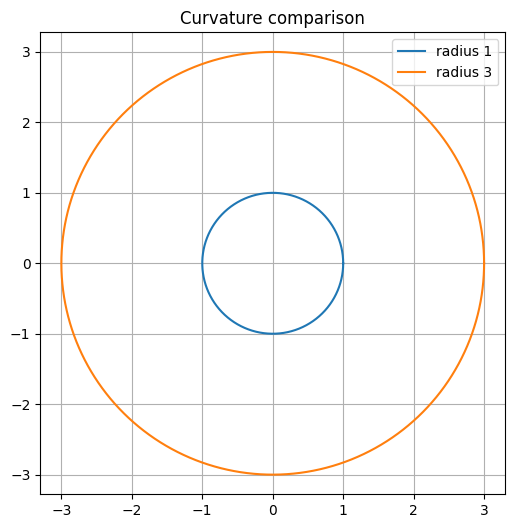

In [51]:
t = np.linspace(0, 2*np.pi, 1000)

R1 = np.column_stack([np.cos(t), np.sin(t), np.zeros_like(t)])
R2 = np.column_stack([3*np.cos(t), 3*np.sin(t), np.zeros_like(t)])

for name, R in [("unit circle", R1), ("radius 3 circle", R2)]:
    V = numerical_derivative(R, t)
    A = numerical_derivative(V, t)
    kappa = curvature_from_va(V, A)
    interior = slice(5, -5)
    print(name)
    print("  mean curvature:", kappa[interior].mean())

plt.figure(figsize=(6, 6))
plt.plot(R1[:,0], R1[:,1], label="radius 1")
plt.plot(R2[:,0], R2[:,1], label="radius 3")
plt.axis("equal")
plt.legend()
plt.grid(True)
plt.title("Curvature comparison")
plt.show()

---

# Formula summary

## Cross product

$$
\mathbf a\times \mathbf b
=
\left\langle
a_2b_3-a_3b_2,\;
a_3b_1-a_1b_3,\;
a_1b_2-a_2b_1
\right\rangle.
$$

## Area

$$
\text{Area of parallelogram}=|\mathbf a\times\mathbf b|,
\qquad
\text{Area of triangle}=\frac12|\mathbf a\times\mathbf b|.
$$

## Plane through three points

$$
\mathbf n=(Q-P)\times(R-P),
\qquad
\mathbf n\cdot(\mathbf x-P)=0.
$$

## Scalar triple product

$$
\text{Signed volume}=\mathbf a\cdot(\mathbf b\times\mathbf c).
$$

## Motion

$$
\mathbf v(t)=\mathbf r'(t),\qquad
\text{speed}=|\mathbf v(t)|,\qquad
\mathbf a(t)=\mathbf r''(t).
$$

## Arc length

$$
L=\int_a^b|\mathbf r'(t)|\,dt.
$$

## Unit tangent

$$
\mathbf T(t)=\frac{\mathbf r'(t)}{|\mathbf r'(t)|}.
$$

## Curvature

$$
\kappa(t)=
\frac{|\mathbf r'(t)\times\mathbf r''(t)|}{|\mathbf r'(t)|^3}.
$$

# End of Chapter 5 Lab

You have now used Python to explore the central objects of Chapter 5:

- cross products,
- orientation,
- area,
- normal vectors,
- scalar triple products,
- vector-valued curves,
- velocity,
- acceleration,
- arc length,
- unit tangents,
- curvature,
- and trajectories in data and optimization.

These ideas prepare for line integrals, vector fields, surface orientation, flux, curl, Stokes' theorem, and the divergence theorem.